# ITERATIVE POLICY EVALUATION

![algorithm](images/iterative_policy_eval.png)

In [47]:
import numpy as np

K = 10        # number of states
A = 4         # number of actions
gamma = 0.9

theta = 1e-5

terminal = K - 1

# -------------------------
# Initial value function
# -------------------------
V = np.random.randn(K)
V[terminal] = 0.0

#policy pi(a | s) is a matrix s x a
pi = np.zeros((K, A))

for s in range(K):
    logits = np.random.randn(A)

    exp_logits = np.exp(logits - np.max(logits))
    pi[s] = exp_logits / np.sum(exp_logits)

#dynamics p(s′,r∣s,a) is a matrix P[s, a, s_prime] where each entry has a R[s, a, s_prime]
P = np.zeros((K, A, K)) #P(St+1​=s′∣St​=s,At​=a)

for s in range(K):
    for a in range(A):
        probs = np.random.rand(K)
        probs /= probs.sum()

        P[s, a] = probs

R = np.random.normal( #R[s, a, s_prime] reward for s --> a --> s'
    loc=0,
    scale=1,
    size=(K, A, K)
)

#terminal state
P[terminal, :, :] = 0
P[terminal, :, terminal] = 1
R[terminal, :, :] = 0

def policy_eval():
    

    history = [V.copy()]

    while True:

        delta = 0.0

        for s in range(K):

            if s == terminal:
                continue

            v = V[s]

            new_value = 0.0

            for a in range(A):

                for s_prime in range(K):

                    new_value += (
                        pi[s, a]
                        * P[s, a, s_prime]
                        * (
                            R[s, a, s_prime]
                            + gamma * V[s_prime]
                        )
                    )

            V[s] = new_value

            delta = max(delta, abs(v - V[s]))

        # save V after one complete sweep
        history.append(V.copy())

        if delta < theta:
            break

    return V, history

In [48]:
final_V, history = policy_eval()

In [59]:
import matplotlib.pyplot as plt


In [60]:

def plot_v(final_V):
    # -------------------------
    # Visualize final V(s)
    # -------------------------
    plt.figure(figsize=(8, 4))

    plt.bar(range(K), final_V)

    plt.xlabel("State s")
    plt.ylabel("final_V(s)")
    plt.title("Final State-Value Function")

    plt.xticks(range(K))
    plt.grid(axis="y", alpha=0.3)

    plt.show()


    # -------------------------
    # Visualize policy pi(a|s)
    # -------------------------

    plt.figure(figsize=(8, 5))

    plt.imshow(pi, aspect="auto")

    plt.xlabel("Action a")
    plt.ylabel("State s")
    plt.title("Policy π(a | s)")

    plt.xticks(range(A))
    plt.yticks(range(K))

    plt.colorbar(label="π(a | s)")

    plt.show()

In [58]:

def plot_history(history):
    history = np.array(history)

    plt.figure(figsize=(9, 5))

    for s in range(K):
        plt.plot(history[:, s], label=f"s={s}")

    plt.xlabel("Iteration")
    plt.ylabel("V(s)")
    plt.title("Iterative Policy Evaluation")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

# POLICY IMPROVEMENT

![algorithm](images/iterative_policy_improvement.png)


In [56]:
def policy_improvement():

    while True:

        final_v, history = policy_eval()

        stable = True
        for s in range(K):
            if s == terminal:
                continue
            
            old_a = np.argmax(pi[s])

            max_a = None
            max_value = float("-inf")
            for a in range(A):

                new_value = 0.0
                for s_prime in range(K):

                    new_value += (
                        P[s, a, s_prime]
                        * (
                            R[s, a, s_prime]
                            + gamma * V[s_prime]
                        )
                    )

                if new_value > max_value:
                    max_value = new_value
                    max_a = a

            # make policy greedy
            pi[s] = 0.0
            pi[s, max_a] = 1.0
            
            if max_a != old_a:
                stable = False

        if stable:
            return final_v, history


### DETEMINISTIC POLICY

In [ ]:
#INITIALIZE MDP
# -------------------------
# Initial value function
# -------------------------
V = np.random.randn(K)
V[terminal] = 0.0

#policy pi(a | s) is a matrix s x a
pi = np.zeros((K, A))


#!deterministic policy
for s in range(K):
    idx = np.random.choice(A)
    pi[s][idx] = 1.0

#dynamics p(s′,r∣s,a) is a matrix P[s, a, s_prime] where each entry has a R[s, a, s_prime]
P = np.zeros((K, A, K)) #P(St+1​=s′∣St​=s,At​=a)

for s in range(K):
    for a in range(A):
        probs = np.random.rand(K)
        probs /= probs.sum()

        P[s, a] = probs

R = np.random.normal( #R[s, a, s_prime] reward for s --> a --> s'
    loc=0,
    scale=1,
    size=(K, A, K)
)

#terminal state
P[terminal, :, :] = 0
P[terminal, :, terminal] = 1
R[terminal, :, :] = 0

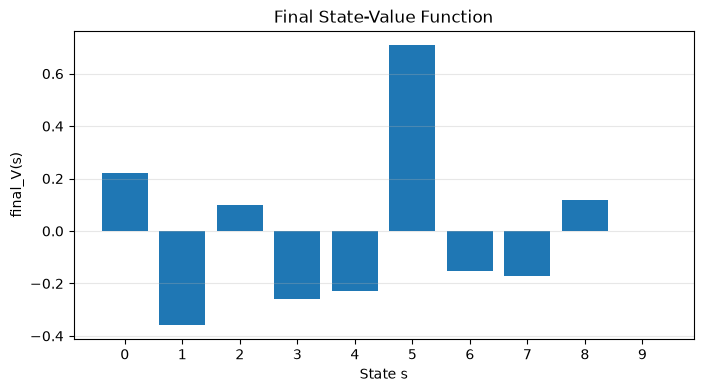

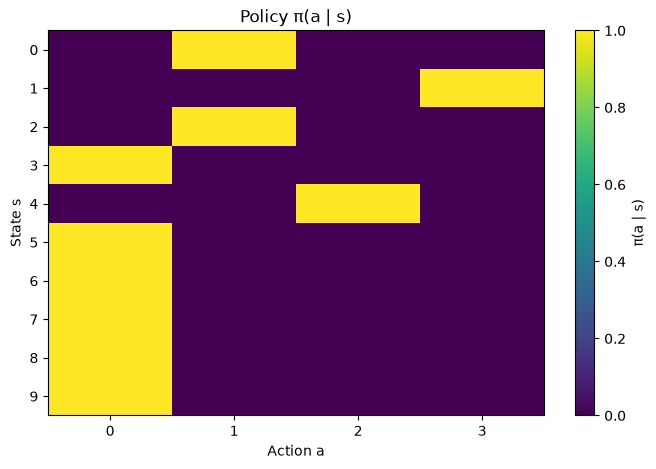

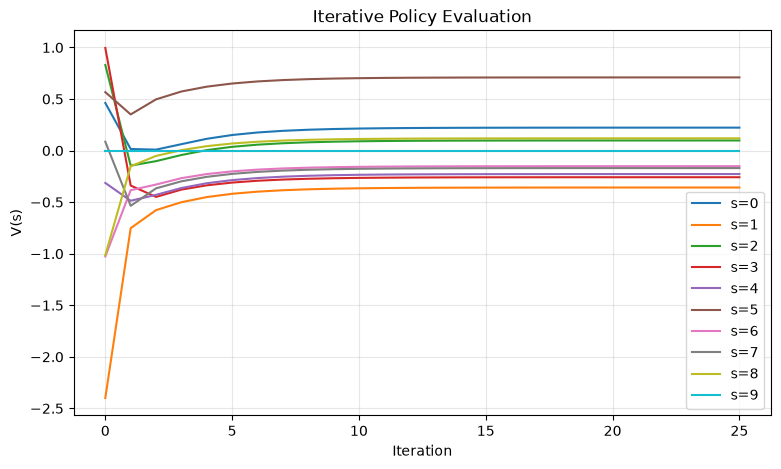

In [62]:
v_init, history = policy_eval()
plot_v(v_init)
plot_history(history)

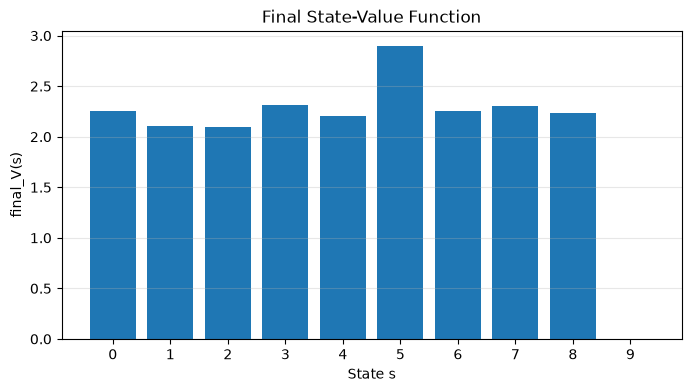

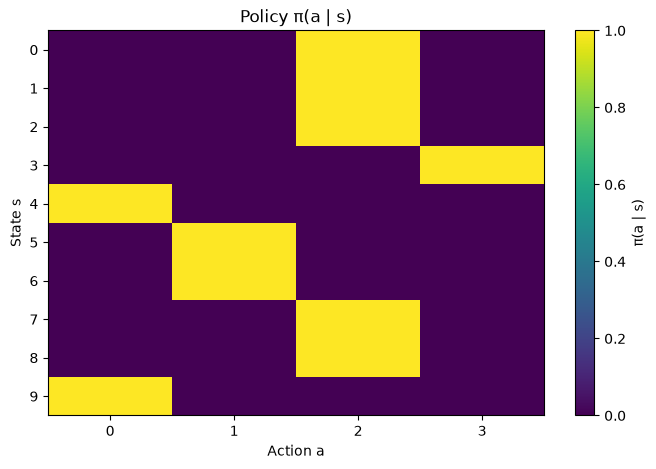

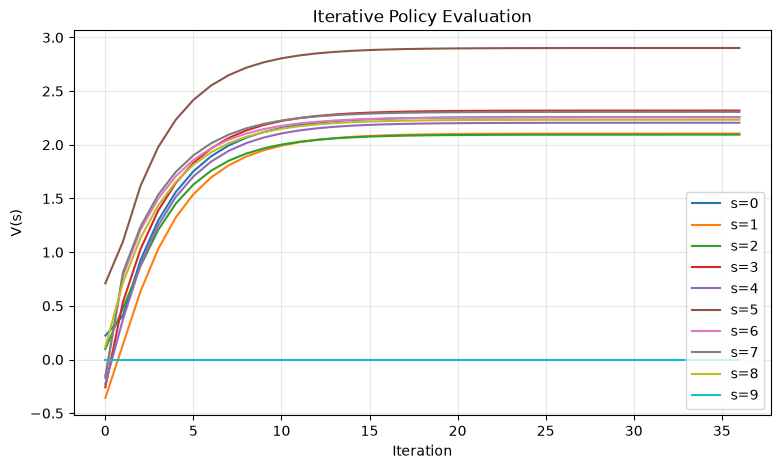

In [63]:
final_V, final_history = policy_improvement()
plot_v(final_V)
plot_history(final_history)